**Feature Scaling** :

Feature Scaling is the process of transforming numerical features so that they have a similar scale or range. It is one of the most important preprocessing steps in Machine Learning because many algorithms are sensitive to the magnitude of feature values.

Feature Scaling is a feature engineering technique used to normalize the range of independent variables (features) in your data. It ensures that all your features are on an equal playing field so that variables with massive numbers don't bullying or overpower variables with smaller numbers.

Real-Life Analogy

Imagine a race between:

Ant (weight in grams)
Elephant (weight in kilograms)

If we compare them directly, the elephant's weight dominates.

To compare fairly, we convert both into a common scale.

Feature Scaling does the same for machine learning features.

**Types of Feature Scaling :**



**1. Standardization (Z-score Normalization)**


Standardization is almost always your safest baseline choice. It takes your raw data, centers it around zero, and flattens out its variance without stripping away the statistical significance of your extreme values.

When you run a column through a standardizer, it applies the classic Z-score formula to every single data point.

Because every data point is processed by subtracting the mean (μ) and dividing by the standard deviation (σ), the entire dataset undergoes a structural transformation. No matter what crazy units or scales your data started with (millions of dollars, fractions of a second, or ages), the output dataset will always have:

A Mean (μ) of exactly 0
A Standard Deviation (σ) of exactly 1


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Method 1 -  For Standardization

In [6]:
total_bill = list(df['total_bill'])

In [9]:
total_bill

[16.99,
 10.34,
 21.01,
 23.68,
 24.59,
 25.29,
 8.77,
 26.88,
 15.04,
 14.78,
 10.27,
 35.26,
 15.42,
 18.43,
 14.83,
 21.58,
 10.33,
 16.29,
 16.97,
 20.65,
 17.92,
 20.29,
 15.77,
 39.42,
 19.82,
 17.81,
 13.37,
 12.69,
 21.7,
 19.65,
 9.55,
 18.35,
 15.06,
 20.69,
 17.78,
 24.06,
 16.31,
 16.93,
 18.69,
 31.27,
 16.04,
 17.46,
 13.94,
 9.68,
 30.4,
 18.29,
 22.23,
 32.4,
 28.55,
 18.04,
 12.54,
 10.29,
 34.81,
 9.94,
 25.56,
 19.49,
 38.01,
 26.41,
 11.24,
 48.27,
 20.29,
 13.81,
 11.02,
 18.29,
 17.59,
 20.08,
 16.45,
 3.07,
 20.23,
 15.01,
 12.02,
 17.07,
 26.86,
 25.28,
 14.73,
 10.51,
 17.92,
 27.2,
 22.76,
 17.29,
 19.44,
 16.66,
 10.07,
 32.68,
 15.98,
 34.83,
 13.03,
 18.28,
 24.71,
 21.16,
 28.97,
 22.49,
 5.75,
 16.32,
 22.75,
 40.17,
 27.28,
 12.03,
 21.01,
 12.46,
 11.35,
 15.38,
 44.3,
 22.42,
 20.92,
 15.36,
 20.49,
 25.21,
 18.24,
 14.31,
 14.0,
 7.25,
 38.07,
 23.95,
 25.71,
 17.31,
 29.93,
 10.65,
 12.43,
 24.08,
 11.69,
 13.42,
 14.26,
 15.95,
 12.48,
 29.8,
 8.52,

<Axes: ylabel='Count'>

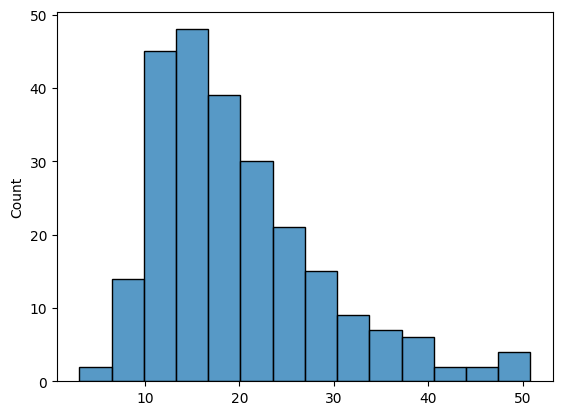

In [15]:
sns.histplot(total_bill)

In [10]:
# Mean & sd
mean = np.mean(total_bill)
std = np.std(total_bill)

In [11]:
mean, std

(np.float64(19.78594262295082), np.float64(8.884150577771132))

In [14]:
# Calculate the Z-score for each item in total_bill (Standardization)
normalized_total_bill = []
for i in total_bill:
  z_score = (i - mean) / std
  normalized_total_bill.append(z_score)
print(normalized_total_bill)

[np.float64(-0.3147113050904943), np.float64(-1.0632353132988692), np.float64(0.13777989987156145), np.float64(0.43831510316725475), np.float64(0.540744704290506), np.float64(0.6195367051545455), np.float64(-1.2399545152367863), np.float64(0.7985071071171495), np.float64(-0.5342033074974614), np.float64(-0.5634689078183903), np.float64(-1.0711145133852733), np.float64(1.7417599174609364), np.float64(-0.49143050702841123), np.float64(-0.15262490331304146), np.float64(-0.557840907756673), np.float64(0.2019391005751361), np.float64(-1.0643609133112126), np.float64(-0.3935033059545337), np.float64(-0.31696250511518104), np.float64(0.09725829942719795), np.float64(-0.2100305039425557), np.float64(0.05673669898283484), np.float64(-0.45203450659639155), np.float64(2.2100095225958003), np.float64(0.003833498402694168), np.float64(-0.2224121040783337), np.float64(-0.7221785095588127), np.float64(-0.7987193103981653), np.float64(0.21544630072325727), np.float64(-0.015301701807144186), np.float64

<Axes: ylabel='Count'>

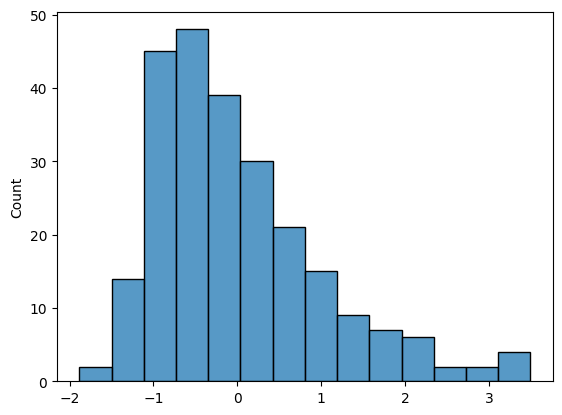

In [16]:
sns.histplot(normalized_total_bill)

**Method 2 -  For Standardization using sklearn**

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
# scaler = StandardScaler() creates an instance of the StandardScaler class
# from scikit-learn. This scaler object will be used later to apply
# standardization (Z-score normalization) to your data, transforming it so
# that it has a mean of 0 and a standard deviation of 1. It's an essential
# step in many machine learning workflows to ensure features are on a
# comparable scale.

scaler = StandardScaler()

Creating an object (an instance) of StandardScaler is crucial because it allows the scaler to learn the mean and standard deviation from your training data. Once learned, these specific mean and standard deviation values are stored within the scaler object. You can then use this same scaler object to transform new data (like your test set) consistently, ensuring that the same scaling parameters are applied. This prevents data leakage and ensures that your model is evaluated fairly on unseen data.

In [19]:
# The fit() method in scikit-learn is a crucial step for many preprocessing
# and machine learning models. For a StandardScaler, fit() calculates the
# mean and standard deviation of the data it's given. It doesn't modify the
# data itself, but rather learns these statistics. These learned statistics
# are then stored inside the scaler object and will be used later by the
# transform() method to actually scale the data.

scaler.fit(df[['total_bill']])

StandardScaler()

In [20]:
scaler.transform(df[['total_bill']])


array([[-3.14711305e-01],
       [-1.06323531e+00],
       [ 1.37779900e-01],
       [ 4.38315103e-01],
       [ 5.40744704e-01],
       [ 6.19536705e-01],
       [-1.23995452e+00],
       [ 7.98507107e-01],
       [-5.34203307e-01],
       [-5.63468908e-01],
       [-1.07111451e+00],
       [ 1.74175992e+00],
       [-4.91430507e-01],
       [-1.52624903e-01],
       [-5.57840908e-01],
       [ 2.01939101e-01],
       [-1.06436091e+00],
       [-3.93503306e-01],
       [-3.16962505e-01],
       [ 9.72582994e-02],
       [-2.10030504e-01],
       [ 5.67366990e-02],
       [-4.52034507e-01],
       [ 2.21000952e+00],
       [ 3.83349840e-03],
       [-2.22412104e-01],
       [-7.22178510e-01],
       [-7.98719310e-01],
       [ 2.15446301e-01],
       [-1.53017018e-02],
       [-1.15215771e+00],
       [-1.61629703e-01],
       [-5.31952107e-01],
       [ 1.01760699e-01],
       [-2.25788904e-01],
       [ 4.81087904e-01],
       [-3.91252106e-01],
       [-3.21464905e-01],
       [-1.2

In [21]:
# fit and transform in one line
scaler.fit_transform(df[['tip']])

array([[-1.43994695e+00],
       [-9.69205340e-01],
       [ 3.63355539e-01],
       [ 2.25754144e-01],
       [ 4.43019505e-01],
       [ 1.23965916e+00],
       [-7.22971264e-01],
       [ 8.81527488e-02],
       [-7.51939979e-01],
       [ 1.67816714e-01],
       [-9.32994446e-01],
       [ 1.44968234e+00],
       [-1.03438495e+00],
       [ 1.24660453e-03],
       [ 1.57309619e-02],
       [ 6.67527044e-01],
       [-9.61963161e-01],
       [ 5.15441291e-01],
       [ 3.63355539e-01],
       [ 2.54722859e-01],
       [ 7.83401903e-01],
       [-1.79807863e-01],
       [-5.56401155e-01],
       [ 3.31816444e+00],
       [ 1.31605821e-01],
       [-4.76737189e-01],
       [-7.22971264e-01],
       [-7.22971264e-01],
       [ 9.42729834e-01],
       [ 1.24660453e-03],
       [-1.12129109e+00],
       [-3.60862330e-01],
       [ 1.24660453e-03],
       [-3.97073223e-01],
       [ 1.96785429e-01],
       [ 4.35777326e-01],
       [-7.22971264e-01],
       [ 5.19418554e-02],
       [-4.9

In [23]:
# convert into dataframe
pd.DataFrame(scaler.fit_transform(df[['tip']]), columns=['tip'])

,tip
0,-1.439947
1,-0.969205
2,0.363356
3,0.225754
4,0.443020
...,...
239,2.115963
240,-0.722971
241,-0.722971
242,-0.904026


**2. Normalization (Min-Max Scaling)**

While Standardization sets your data's mean to 0 and stretches it out based on standard deviations, Normalization (most commonly referred to as Min-Max Scaling) takes a completely different approach.

It acts like a data compressor, taking any numerical column and squeezing every single value strictly into a fixed, predictable box—usually between 0 and 1 (or -1 and 1).

The Min-Max scaler finds the absolute lowest value (Xmin) and highest value (Xmax) in your column, then recalculates every data point.

The absolute minimum value in your raw
data automatically becomes exactly 0.

The absolute maximum value in your raw data automatically becomes exactly 1.

Every other number becomes a precise decimal fraction between 0.0 and 1.0.



In [26]:
df = sns.load_dataset('taxis')

In [27]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [29]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
min_max = MinMaxScaler()

In [31]:
min_max.fit_transform(df[['fare','total','distance','tip']])

array([[0.04026846, 0.06713923, 0.04359673, 0.06475904],
       [0.02684564, 0.0461042 , 0.02152589, 0.        ],
       [0.04362416, 0.07411249, 0.0373297 , 0.07108434],
       ...,
       [0.10067114, 0.09220839, 0.11280654, 0.        ],
       [0.03355705, 0.03169663, 0.03051771, 0.        ],
       [0.09395973, 0.10869064, 0.10490463, 0.10120482]])

In [33]:
# When you get new data, you use 'min_max.transform()' to scale it.
# This makes sure the new data is scaled in the exact same way as the
# data you used before. It's like using the same measuring cup for all your
# ingredients so everything fits together. No need to do fit again.

min_max.transform([[5,6,7,9]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.02684564, 0.02708621, 0.19073569, 0.27108434]])

In [34]:
pd.DataFrame(min_max.fit_transform(df[['fare','total','distance','tip']]), columns=['fare','total','distance','tip'])


,fare,total,distance,tip
0,0.040268,0.067139,0.043597,0.064759
1,0.026846,0.046104,0.021526,0.000000
2,0.043624,0.074112,0.037330,0.071084
3,0.174497,0.205452,0.209809,0.185241
4,0.053691,0.069733,0.058856,0.033133
...,...,...,...,...
6428,0.023490,0.029161,0.020436,0.031928
6429,0.382550,0.331374,0.510627,0.000000
6430,0.100671,0.092208,0.112807,0.000000
6431,0.033557,0.031697,0.030518,0.000000


In [ ]:
# Prefer
# Standardization (Z-score Normalization) - Machine learning
# Normalization (Min-Max Scaling) - Deep learning (images)

**3. Unit Vector**

####**Unit Vector (Feature Scaling) :**

In data science, machine learning models don't just care about how big a number is; they often care about the direction the data is pointing.

**What is a Unit Vector?**

A Unit Vector is a vector whose magnitude (length) is exactly 1.The process of converting a regular vector into a unit vector is called Vector Normalization or L2 Normalization.
Instead of scaling individual columns one by one, Unit Vector scaling scales an entire row at once so that the geometric length of that row equals 1.

In Machine Learning, Unit Vector Scaling (also called Normalization by Vector Length) transforms data so that the magnitude of each observation becomes 1 while preserving its direction.



In [37]:
df = sns.load_dataset('iris')

In [38]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [39]:
from sklearn.preprocessing import normalize

In [40]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [41]:
normalize(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

array([[0.80377277, 0.55160877, 0.22064351, 0.0315205 ],
       [0.82813287, 0.50702013, 0.23660939, 0.03380134],
       [0.80533308, 0.54831188, 0.2227517 , 0.03426949],
       [0.80003025, 0.53915082, 0.26087943, 0.03478392],
       [0.790965  , 0.5694948 , 0.2214702 , 0.0316386 ],
       [0.78417499, 0.5663486 , 0.2468699 , 0.05808704],
       [0.78010936, 0.57660257, 0.23742459, 0.0508767 ],
       [0.80218492, 0.54548574, 0.24065548, 0.0320874 ],
       [0.80642366, 0.5315065 , 0.25658935, 0.03665562],
       [0.81803119, 0.51752994, 0.25041771, 0.01669451],
       [0.80373519, 0.55070744, 0.22325977, 0.02976797],
       [0.786991  , 0.55745196, 0.26233033, 0.03279129],
       [0.82307218, 0.51442011, 0.24006272, 0.01714734],
       [0.8025126 , 0.55989251, 0.20529392, 0.01866308],
       [0.81120865, 0.55945424, 0.16783627, 0.02797271],
       [0.77381111, 0.59732787, 0.2036345 , 0.05430253],
       [0.79428944, 0.57365349, 0.19121783, 0.05883625],
       [0.80327412, 0.55126656,

In [43]:
# Apply Unit Vector Scaling (L2 Normalization) to the selected features and create a DataFrame
pd.DataFrame(normalize(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]), columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

,sepal_length,sepal_width,petal_length,petal_width
0,0.803773,0.551609,0.220644,0.031521
1,0.828133,0.507020,0.236609,0.033801
2,0.805333,0.548312,0.222752,0.034269
3,0.800030,0.539151,0.260879,0.034784
4,0.790965,0.569495,0.221470,0.031639
...,...,...,...,...
145,0.721557,0.323085,0.560015,0.247699
146,0.729654,0.289545,0.579090,0.220054
147,0.716539,0.330710,0.573231,0.220474
148,0.674671,0.369981,0.587616,0.250281
